<a href="https://colab.research.google.com/github/yesahek/Machine_Learning/blob/main/Deep%20Learning/PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# check PyTorch version
torch.__version__

'2.11.0+cu128'

## 1. Data (preparing and loading)
Data can be almost anything

Machin learning is a game of two parts:
1. Get data into a numberical repressentaion.
2. Build a model to learn patterns in that numberical representaiton.





In [2]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X+bias
X[:10], y[:10], len(X)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50)

In [3]:
# Spliting data into training and test sets

In [4]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test),len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train, train_labels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
  """
  Plots traing data, test data and compares predictions.
  """
  plt.figure(figsize=(10,7))

  # plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  #Are there predicion?
  if predictions is not None:
    #plot the predictions if they exist
    plt.scatter(test_data, predictions, c="r",s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size":14});


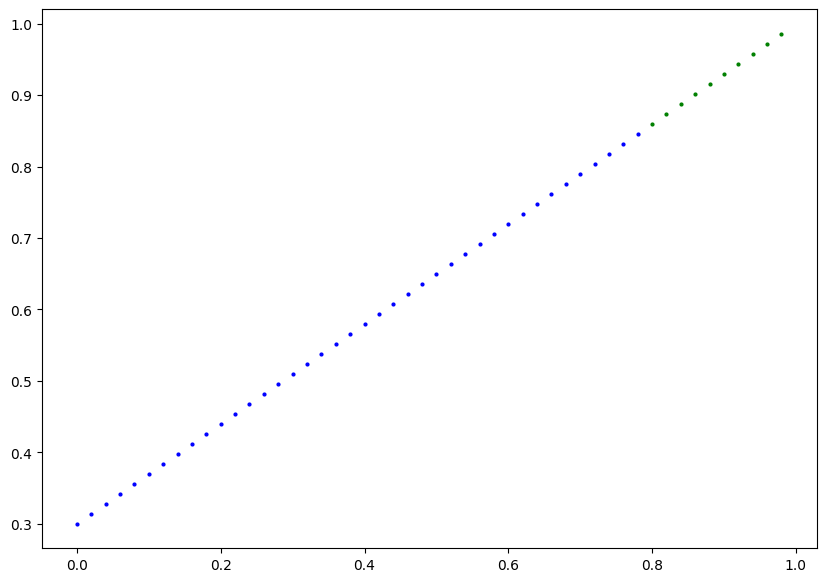

In [6]:
plot_predictions();

# Build Model

In [7]:
# Create linear regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float))

  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias



In [8]:
#Create a Random seed
torch.manual_seed(42)
model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
# Making prediction using `torch.inference_mode()`
 # Make Predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

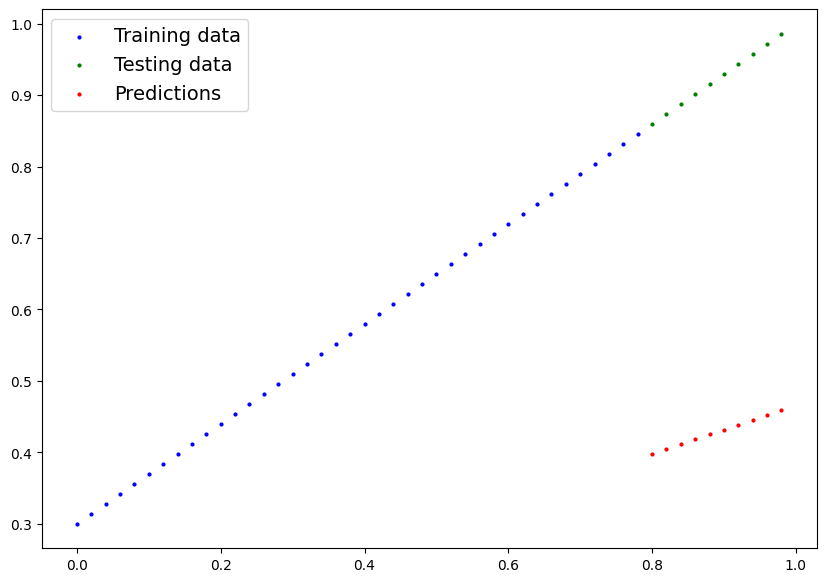

In [11]:
plot_predictions(predictions=y_preds)

In [12]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [13]:
### Building a training loop in pytorch

epochs = 200

#Tracking defferent values
epoch_count = []
loss_values = []
test_loss_values = []


### Training
# Loop through the data
for epoch in range(epochs):
  model_0.train()
  # 1. forward pass
  y_pred = model_0(X_train)
  # 2. calculate the loss
  loss = loss_fn(y_pred,y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. perform backpropgation on the loss with respect to the parameters
  loss.backward()
  # 5. Step the optimizer (perform gradient descent)
  optimizer.step()
  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Do the forward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

    # Print out what's happenin
    if epoch % 10 == 0:
      epoch_count.append(epoch)
      loss_values.append(loss)
      test_loss_values.append(test_loss)
      print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
      # print out model state_dict()
      print(model_0.state_dict())

Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.03

In [14]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [15]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

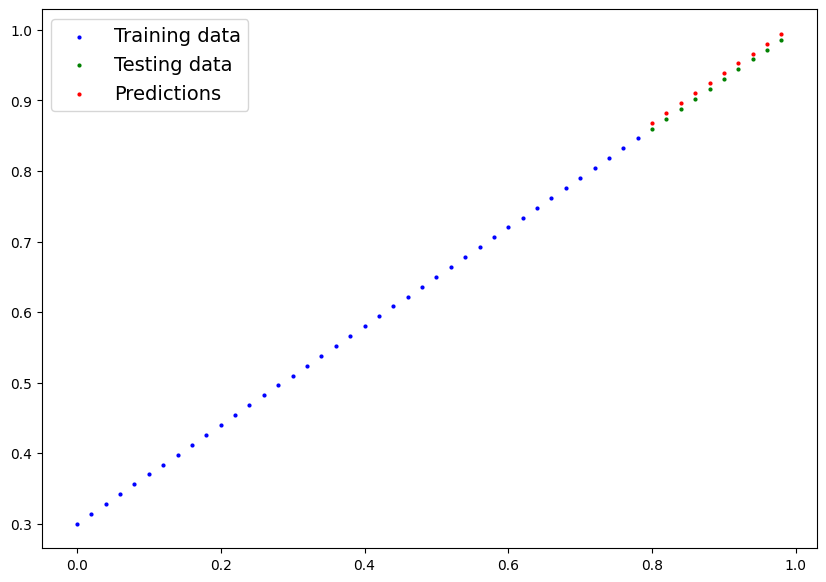

In [16]:
plot_predictions(predictions=y_preds_new)

/tmp/ipykernel_1444/4134905744.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train Loss")


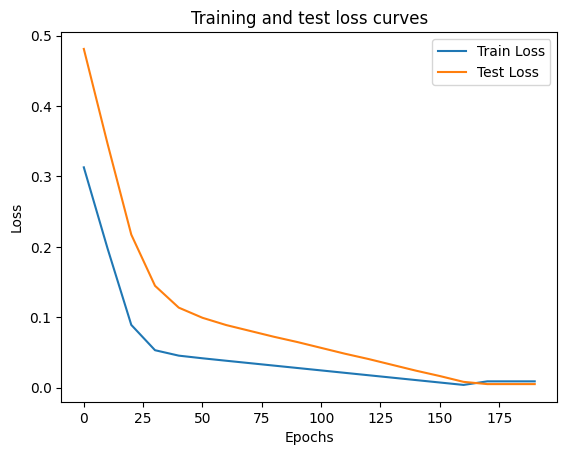

In [17]:
# Plot the loss curves
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

# Saving a model in PyTorch


In [18]:
from pathlib import Path

# Create models direcotry
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to : {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)

Saving model to : models/01_pytorch_workflow_model_0.pth


In [19]:
!ls -l models/

total 4
-rw-r--r-- 1 root root 2117 Jun  3 20:28 01_pytorch_workflow_model_0.pth


## Loading a PyTorch Model

In [20]:
# Instantiate a new instance of out model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [21]:
# Make some predictions with out loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)
loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [22]:
# Compare loaded model preds with original model preds
y_preds_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# Put all together

In [23]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [24]:
# setup device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Data

In [25]:
# Create Weight and bias values
weight = 0.7
bias = 0.3

# Creating range values
start = 0
end = 1
step = 0.02

X = torch.arange(start, end,step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [26]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [27]:
def plot_prediction_sec(train_data = X_train,
                    train_labels = y_train,
                    test_data=X_test,
                    test_labels = y_test,
                    prediction = None):
  plt.figure(figsize=(7,4))
  # Training Data
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  # Testing Data
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
  if prediction is not None:
    # plot prediction in red (prediction model on test data)
    plt.scatter(test_data, prediction, c="r", s=4, label="Predictions")
  plt.legend();

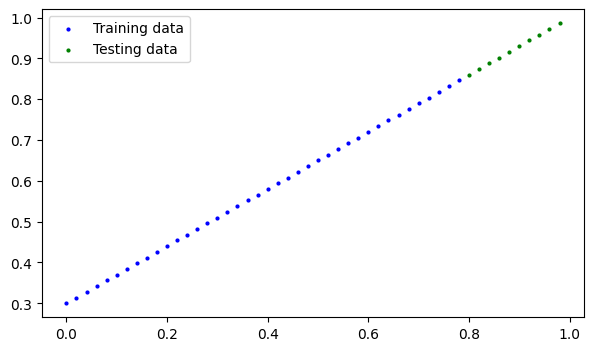

In [28]:
plot_prediction_sec()

# Building PyTorch liner Model


In [29]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # using the nn.Linear()
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)
  def forward(self, x:torch.Tensor) -> torch.Tensor:
      return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [30]:
next(model_1.parameters()).device

device(type='cpu')

In [31]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

# Training

In [32]:
# Create Loss function
loss_fn = nn.L1Loss()

# Create Optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

In [33]:
torch.manual_seed(42)
epochs = 1000

# Put data on the available device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # forward pass
  y_pred = model_1(X_train)

  # calculating the loss
  loss = loss_fn(y_pred, y_train)

  # optimizer zero grad
  optimizer.zero_grad()

  # backpropagation
  loss.backward()

  # set the optimizer
  optimizer.step()

  # Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)

    # calculate the loss
    test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Train Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train Loss: 0.5551779270172119 | Test loss: 0.5739762187004089
Epoch: 100 | Train Loss: 0.006215683650225401 | Test loss: 0.014086711220443249
Epoch: 200 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 300 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 400 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 500 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 600 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 700 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 800 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 900 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882


In [34]:
model_1.state_dict

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [35]:
# Model Evaluation
model_1.eval()

# make a prediction on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

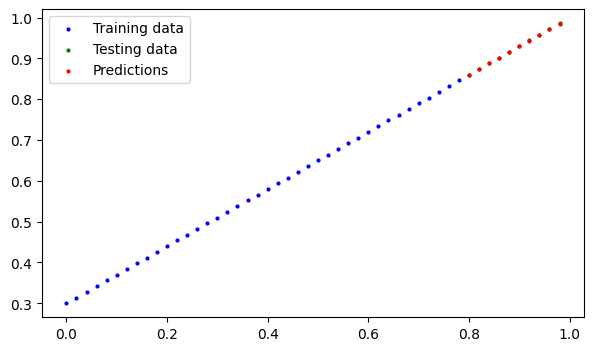

In [40]:
# Check out model prediction visually
plot_prediction_sec(prediction=y_preds.cpu())

# Save and load model


In [44]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# save the model state dict
print(f"Saving model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)

Saving model to :models/01_pytorch_workflow_model_1.pth


# Load model

In [45]:
# Load PyTorch model
# create a new instance of linear regration
loaded_model_1 = LinearRegressionModelV2()
loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# put the loaded model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [48]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [49]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [50]:
# Evaluate loaded model
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')